# Punto 2: Análisis de Puntos de Dolor del Cliente e Impacto por Categoría

**Objetivo:** Identificar los mayores puntos de dolor de los clientes y mapearlos a los productos/categorías que generan experiencias negativas.

**Enfoque — Voz del Cliente (Speech-to-Insights):**
1. **Línea base cuantitativa**: Analizar distribuciones de puntajes de reseñas y correlacionar con métricas operativas (retrasos en entregas, estado de pedidos)
2. **Pipeline NLP sobre texto en portugués**: Tokenizar → eliminar stopwords → lematizar → extraer n-gramas → TF-IDF
3. **Taxonomía de puntos de dolor**: Clasificar reseñas negativas en categorías temáticas usando extracción basada en palabras clave + análisis de frecuencia
4. **Mapeo por categoría**: Cruzar puntos de dolor con categorías de productos para identificar qué productos generan qué quejas
5. **Insights accionables**: Traducir hallazgos en recomendaciones de negocio

**Supuestos:**
- Experiencia negativa = puntaje de reseña 1-2 (14,575 reseñas, 14.7% del total)
- Las reseñas sin texto se incluyen en el análisis cuantitativo, se excluyen del NLP
- El texto está en portugués — utilizamos NLP específico para portugués (stopwords, lematización con spaCy)

---
## 1. Configuración y Carga de Datos

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from wordcloud import WordCloud
import ssl, certifi
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
import nltk
from nltk.corpus import stopwords
import spacy
import re
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.labelcolor'] = '#0033a0'
plt.rcParams['axes.titlecolor'] = '#0033a0'

COLORS = {
    'primary': '#0033a0', 'secondary': '#6699cc', 'accent': '#e3e82a',
    'danger': '#e8a030', 'neutral': '#001a4d'
}

DATA_PATH = '../Dataset_prueba/'

reviews = pd.read_csv(f'{DATA_PATH}order_reviews_dataset.csv')
orders = pd.read_csv(f'{DATA_PATH}orders_dataset.csv')
order_items = pd.read_csv(f'{DATA_PATH}order_items_dataset.csv')
products = pd.read_csv(f'{DATA_PATH}products_dataset.csv')
categories = pd.read_csv(f'{DATA_PATH}product_category_name_translation.csv')

# Parsear fechas
for col in ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
            'order_delivered_customer_date', 'order_estimated_delivery_date']:
    orders[col] = pd.to_datetime(orders[col])

# Calcular métricas de entrega
orders['delivery_delay_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days
orders['delivery_time_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['was_late'] = orders['delivery_delay_days'] > 0

print(f'Reviews: {len(reviews):,} | Orders: {len(orders):,}')

Reviews: 99,224 | Orders: 99,441


---
## 2. Línea Base Cuantitativa — ¿De Dónde Viene la Insatisfacción?

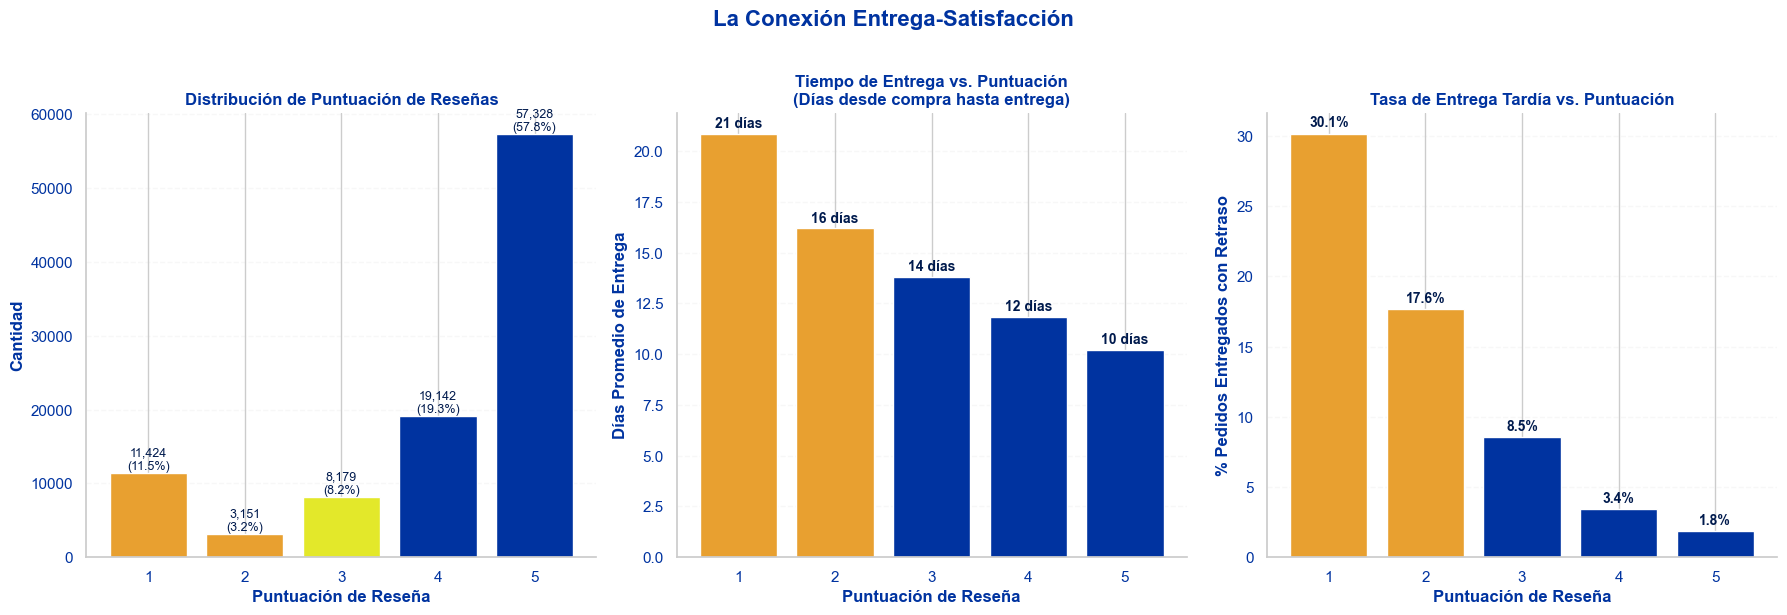


📊 Métrica Clave: 30.1% de reseñas de 1 estrella tuvieron entregas tardías vs 1.8% de reseñas de 5 estrellas


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')

# --- Panel 1: Distribución de puntuaciones ---
ax = axes[0]
ax.set_facecolor('white')
score_counts = reviews['review_score'].value_counts().sort_index()
colors_bar = [COLORS['danger'] if s <= 2 else (COLORS['accent'] if s == 3 else COLORS['primary']) for s in score_counts.index]
bars = ax.bar(score_counts.index, score_counts.values, color=colors_bar, edgecolor='white')
for bar, val in zip(bars, score_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}\n({val/len(reviews)*100:.1f}%)', ha='center', fontsize=9, color=COLORS['neutral'])
ax.set_xlabel('Puntuación de Reseña', color=COLORS['primary'], fontweight='bold')
ax.set_ylabel('Cantidad', color=COLORS['primary'], fontweight='bold')
ax.set_title('Distribución de Puntuación de Reseñas', fontweight='bold', color=COLORS['primary'])
ax.tick_params(colors=COLORS['primary'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.15, linestyle='--')

# --- Panel 2: Tiempo de entrega promedio (días desde compra) ---
ax = axes[1]
ax.set_facecolor('white')
merged_del = reviews.merge(orders[['order_id', 'delivery_delay_days', 'delivery_time_days', 'was_late']], on='order_id')
time_by_score = merged_del.groupby('review_score')['delivery_time_days'].mean()
colors_time = [COLORS['danger'] if v > 15 else COLORS['primary'] for v in time_by_score.values]
bars = ax.bar(time_by_score.index, time_by_score.values, color=colors_time, edgecolor='white')
for bar, val in zip(bars, time_by_score.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.0f} días', ha='center', fontsize=10, fontweight='bold', color=COLORS['neutral'])
ax.set_xlabel('Puntuación de Reseña', color=COLORS['primary'], fontweight='bold')
ax.set_ylabel('Días Promedio de Entrega', color=COLORS['primary'], fontweight='bold')
ax.set_title('Tiempo de Entrega vs. Puntuación\n(Días desde compra hasta entrega)', fontweight='bold', color=COLORS['primary'])
ax.tick_params(colors=COLORS['primary'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.15, linestyle='--')

# --- Panel 3: Tasa de entrega tardía por puntuación ---
ax = axes[2]
ax.set_facecolor('white')
late_rate = merged_del.groupby('review_score')['was_late'].mean() * 100
colors_late = [COLORS['danger'] if v > 10 else COLORS['primary'] for v in late_rate.values]
bars = ax.bar(late_rate.index, late_rate.values, color=colors_late, edgecolor='white')
for bar, val in zip(bars, late_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold', color=COLORS['neutral'])
ax.set_xlabel('Puntuación de Reseña', color=COLORS['primary'], fontweight='bold')
ax.set_ylabel('% Pedidos Entregados con Retraso', color=COLORS['primary'], fontweight='bold')
ax.set_title('Tasa de Entrega Tardía vs. Puntuación', fontweight='bold', color=COLORS['primary'])
ax.tick_params(colors=COLORS['primary'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.15, linestyle='--')

plt.suptitle('La Conexión Entrega-Satisfacción', fontsize=16, fontweight='bold', y=1.02, color=COLORS['primary'])
plt.tight_layout()
plt.savefig('../outputs/02_delivery_satisfaction.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f'\n📊 Métrica Clave: {late_rate.iloc[0]:.1f}% de reseñas de 1 estrella tuvieron entregas tardías vs {late_rate.iloc[-1]:.1f}% de reseñas de 5 estrellas')

---
## 3. Pipeline NLP — Extracción de Puntos de Dolor del Texto en Portugués

Construimos un pipeline NLP personalizado para texto en portugués:
1. Limpiar y normalizar texto
2. Eliminar stopwords en portugués + palabras de ruido específicas del dominio
3. Aplicar lematización con spaCy (`pt_core_news_sm`)
4. Extraer unigramas, bigramas y trigramas mediante TF-IDF

> **Decisión metodológica — Lematización vs. Stemming:** Optamos por lematización con spaCy (`pt_core_news_sm`) en lugar del stemmer RSLP de NLTK. Mientras que el stemming trunca las palabras a raíces ilegibles ("entrega" → "entreg"), la lematización preserva formas legibles del portugués ("entrega" → "entrega", "entregaram" → "entregar"). Esto produce nubes de palabras y análisis TF-IDF más interpretables sin sacrificar la capacidad de agrupar variantes morfológicas. Alternativas consideradas: (1) RSLP Stemming — descartado por producir raíces truncadas poco profesionales para visualización; (2) Modelos transformer (BERTimbau/BERTopic) — descartados por agregar dependencias pesadas (PyTorch) sin beneficio proporcional para este volumen de datos.

In [15]:
# --- Portuguese NLP Setup ---
pt_stopwords = set(stopwords.words('portuguese'))
# Agregar palabras de ruido específicas del dominio
custom_stops = {'produto', 'compra', 'comprei', 'recebi', 'ainda', 'pois', 'ja', 'so',
                'seria', 'fazer', 'muito', 'pode', 'tambem', 'vai', 'aqui', 'la',
                'tudo', 'acho', 'bem', 'ser', 'ter', 'vez', 'vezes', 'dia', 'dias',
                'voces', 'vc', 'vcs', 'nao', 'nada', 'nem', 'nunca', 'pra', 'pro'}
all_stops = pt_stopwords | custom_stops

nlp = spacy.load('pt_core_news_sm')

# Etiquetas POS a excluir: preposiciones, determinantes, pronombres, conjunciones, auxiliares
EXCLUDE_POS = {'ADP', 'DET', 'PRON', 'CONJ', 'CCONJ', 'SCONJ', 'AUX', 'PART', 'NUM', 'PUNCT', 'SYM', 'X'}

def clean_text(text: str) -> str:
    """Clean, normalize, and lemmatize Portuguese review text."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-záàâãéèêíïóôõöúüçñ\s]', ' ', text)  # keep Portuguese chars
    text = re.sub(r'\d+', '', text)
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc
              if token.lemma_ not in all_stops
              and not token.is_stop
              and token.pos_ not in EXCLUDE_POS
              and len(token.lemma_) > 2
              and token.is_alpha]
    return ' '.join(tokens)

# Preparar reseñas negativas
neg_reviews = reviews[reviews['review_score'] <= 2].copy()
neg_with_text = neg_reviews[neg_reviews['review_comment_message'].notna()].copy()
neg_with_text['clean_text'] = neg_with_text['review_comment_message'].apply(clean_text)
neg_with_text = neg_with_text[neg_with_text['clean_text'].str.len() > 5]  # drop empty/tiny

# También preparar reseñas positivas para comparación
pos_reviews = reviews[reviews['review_score'] >= 4].copy()
pos_with_text = pos_reviews[pos_reviews['review_comment_message'].notna()].copy()
pos_with_text['clean_text'] = pos_with_text['review_comment_message'].apply(clean_text)
pos_with_text = pos_with_text[pos_with_text['clean_text'].str.len() > 5]

print(f'Negative reviews with usable text: {len(neg_with_text):,}')
print(f'Positive reviews with usable text: {len(pos_with_text):,}')

Negative reviews with usable text: 10,297
Positive reviews with usable text: 23,214


In [16]:
# --- TF-IDF: Términos principales en reseñas negativas vs positivas ---
def get_top_ngrams(corpus, n_range=(1,1), top_n=20):
    """Extract top n-grams by TF-IDF score."""
    tfidf = TfidfVectorizer(ngram_range=n_range, max_features=5000, min_df=5)
    matrix = tfidf.fit_transform(corpus)
    scores = matrix.mean(axis=0).A1
    terms = tfidf.get_feature_names_out()
    ranked = sorted(zip(terms, scores), key=lambda x: x[1], reverse=True)
    return ranked[:top_n]

# Unigramas
neg_unigrams = get_top_ngrams(neg_with_text['clean_text'], (1,1), 25)
pos_unigrams = get_top_ngrams(pos_with_text['clean_text'], (1,1), 25)

# Bigramas
neg_bigrams = get_top_ngrams(neg_with_text['clean_text'], (2,2), 25)

# Trigramas
neg_trigrams = get_top_ngrams(neg_with_text['clean_text'], (3,3), 20)

print('🔴 UNIGRAMAS NEGATIVOS PRINCIPALES (TF-IDF)')
for term, score in neg_unigrams[:15]:
    print(f'  {term:30s} {score:.4f}')

print('\n🔴 BIGRAMAS NEGATIVOS PRINCIPALES')
for term, score in neg_bigrams[:15]:
    print(f'  {term:30s} {score:.4f}')

print('\n🟢 UNIGRAMAS POSITIVOS PRINCIPALES (para comparación)')
for term, score in pos_unigrams[:10]:
    print(f'  {term:30s} {score:.4f}')

🔴 UNIGRAMAS NEGATIVOS PRINCIPALES (TF-IDF)
  entregar                       0.0601
  chegar                         0.0450
  vir                            0.0344
  entrega                        0.0335
  prazo                          0.0273
  loja                           0.0228
  pedido                         0.0207
  receber                        0.0188
  gostar                         0.0178
  aguardar                       0.0173
  esperar                        0.0157
  pedir                          0.0150
  recebir                        0.0140
  lannister                      0.0138
  qualidade                      0.0137

🔴 BIGRAMAS NEGATIVOS PRINCIPALES
  prazo entrega                  0.0132
  nota fiscal                    0.0122
  entrar contato                 0.0112
  dinheiro volta                 0.0095
  vir defeito                    0.0083
  entregar prazo                 0.0077
  péssimo qualidade              0.0076
  chegar prazo                   0.0055
  v

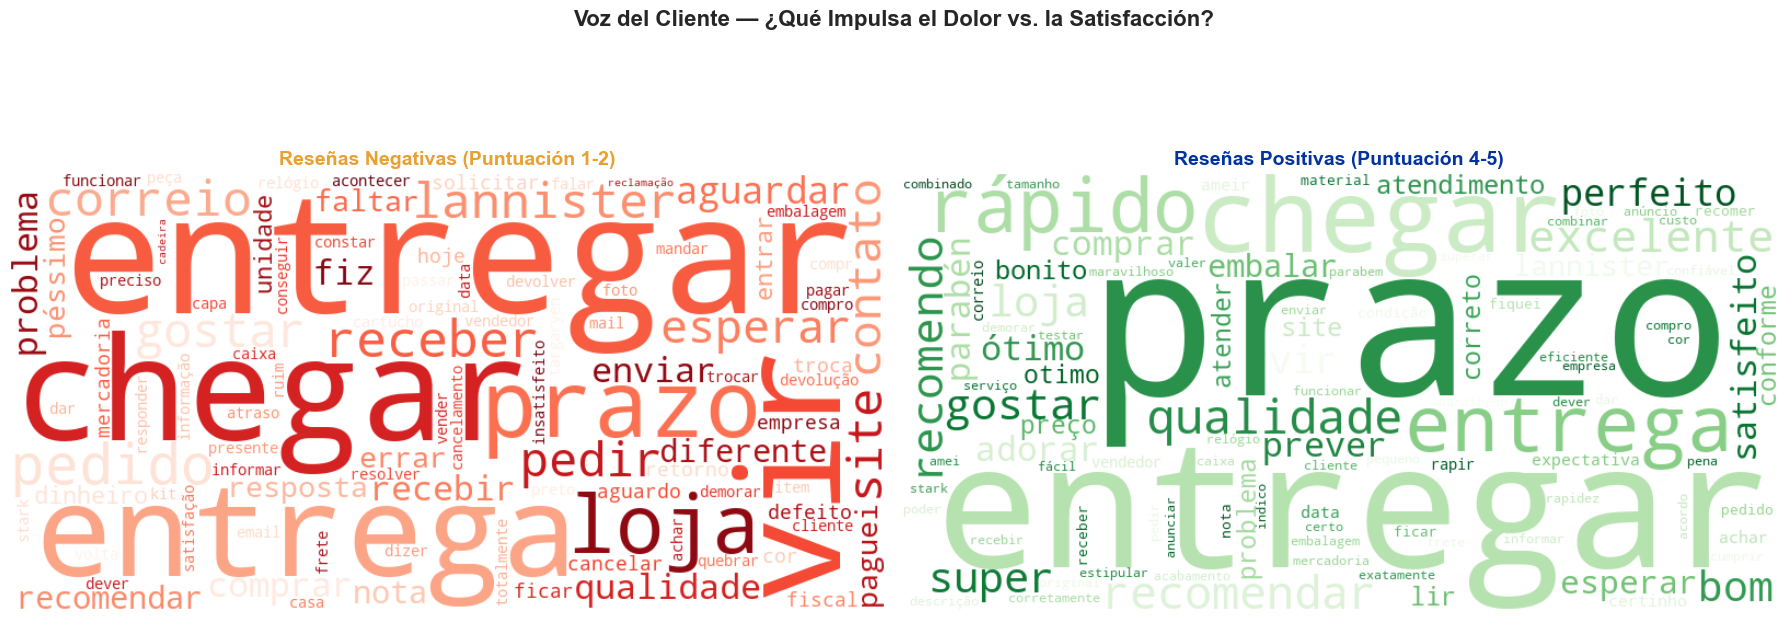

In [17]:
# --- Nubes de Palabras: Negativas vs Positivas ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

neg_text_all = ' '.join(neg_with_text['clean_text'])
pos_text_all = ' '.join(pos_with_text['clean_text'])

wc_neg = WordCloud(width=800, height=400, background_color='white',
                    colormap='Reds', max_words=100, collocations=False).generate(neg_text_all)
wc_pos = WordCloud(width=800, height=400, background_color='white',
                    colormap='Greens', max_words=100, collocations=False).generate(pos_text_all)

axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].set_title('Reseñas Negativas (Puntuación 1-2)', fontsize=14, fontweight='bold', color='#e8a030')
axes[0].axis('off')

axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].set_title('Reseñas Positivas (Puntuación 4-5)', fontsize=14, fontweight='bold', color='#0033a0')
axes[1].axis('off')

plt.suptitle('Voz del Cliente — ¿Qué Impulsa el Dolor vs. la Satisfacción?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/02_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Taxonomía de Puntos de Dolor — Clasificación de Quejas

Basándonos en el análisis de n-gramas y la revisión manual de muestras, definimos una taxonomía de puntos de dolor usando coincidencia de palabras clave. Este es un enfoque práctico e interpretable que refleja cómo un sistema real de Voz del Cliente categoriza los motivos de contacto.

In [18]:
# --- Taxonomía de Puntos de Dolor (palabras clave en portugués) ---
PAIN_TAXONOMY = {
    'Entrega Tardía / No Recibida': {
        'keywords': ['entrega', 'entregar', 'chegar', 'chegou', 'prazo', 'atraso', 'atrasar', 'demora', 'demorar',
                     'demorou', 'entregue', 'receber', 'recebido', 'aguardando', 'esperando',
                     'dias', 'semanas', 'meses', 'previsao', 'transportadora', 'correios',
                     'atrasado', 'atrasada', 'frete'],
        'color': '#e8a030'
    },
    'Calidad del Producto': {
        'keywords': ['qualidade', 'defeito', 'defeituoso', 'quebrado', 'quebrar', 'ruim',
                     'pessimo', 'pessima', 'horrivel', 'lixo', 'inferior', 'funcionar',
                     'funcionou', 'estragado', 'rachado', 'mal acabado', 'fragil',
                     'danificado', 'estragar', 'falha'],
        'color': '#0033a0'
    },
    'Producto Equivocado / Faltante': {
        'keywords': ['errado', 'errada', 'diferente', 'trocado', 'trocar', 'outro',
                     'faltando', 'faltar', 'incompleto', 'veio', 'enviar', 'descricao',
                     'anuncio', 'foto', 'imagem', 'corresponder', 'especificacao'],
        'color': '#e3e82a'
    },
    'Reembolso / Soporte': {
        'keywords': ['reembolso', 'devolucao', 'devolver', 'dinheiro', 'estorno',
                     'cancelamento', 'cancelar', 'atendimento', 'suporte',
                     'contato', 'resposta', 'responder', 'resolver', 'solucao',
                     'reclamacao', 'procon', 'reclamar'],
        'color': '#6699cc'
    },
    'Daño en Tránsito': {
        'keywords': ['embalagem', 'amassado', 'amassada', 'danificado', 'danificada',
                     'aberto', 'aberta', 'violado', 'violada', 'estourar', 'molhado',
                     'rasgado', 'rasgada', 'caixa'],
        'color': '#001a4d'
    }
}

# NOTA SOBRE ESTRATEGIA DE CLASIFICACIÓN:
# La función classify_pain_point busca palabras clave en el texto original de la reseña
# (review_comment_message), mientras que el análisis TF-IDF usa la columna clean_text
# (lematizada). Esta es una decisión de diseño intencional: la lista de palabras clave
# incluye múltiples formas flexionadas de cada raíz (ej: 'atraso', 'atrasar', 'atrasado',
# 'atrasada'), proporcionando amplia cobertura. Usar texto original para la clasificación
# evita dependencia del lematizador, manteniendo la taxonomía transparente y auditable.

def classify_pain_point(text: str) -> list:
    """Classify review text into pain point categories. Returns all matching categories."""
    if not isinstance(text, str):
        return ['Sin Clasificar']
    text_lower = text.lower()
    matches = []
    for category, info in PAIN_TAXONOMY.items():
        if any(kw in text_lower for kw in info['keywords']):
            matches.append(category)
    return matches if matches else ['Sin Clasificar']

# Aplicar clasificación
neg_with_text['pain_points'] = neg_with_text['review_comment_message'].apply(classify_pain_point)

# Expandir para conteo multi-etiqueta
pain_exploded = neg_with_text.explode('pain_points')

pain_counts = pain_exploded['pain_points'].value_counts()
pain_pcts = (pain_counts / len(neg_with_text) * 100).round(1)

print('\U0001f534 DISTRIBUCIÓN DE PUNTOS DE DOLOR (% de reseñas negativas con texto)')
print('=' * 55)
for pain, pct in pain_pcts.items():
    count = pain_counts[pain]
    print(f'  {pain:35s} {count:>5,} reseñas  ({pct:>5.1f}%)')

print(f'\n\U0001f4cc Nota: Las reseñas pueden coincidir con múltiples categorías. Total negativas con texto: {len(neg_with_text):,}')


🔴 DISTRIBUCIÓN DE PUNTOS DE DOLOR (% de reseñas negativas con texto)
  Entrega Tardía / No Recibida        5,318 reseñas  ( 51.6%)
  Producto Equivocado / Faltante      2,648 reseñas  ( 25.7%)
  Sin Clasificar                      2,194 reseñas  ( 21.3%)
  Reembolso / Soporte                 1,819 reseñas  ( 17.7%)
  Calidad del Producto                1,142 reseñas  ( 11.1%)
  Daño en Tránsito                      496 reseñas  (  4.8%)

📌 Nota: Las reseñas pueden coincidir con múltiples categorías. Total negativas con texto: 10,297


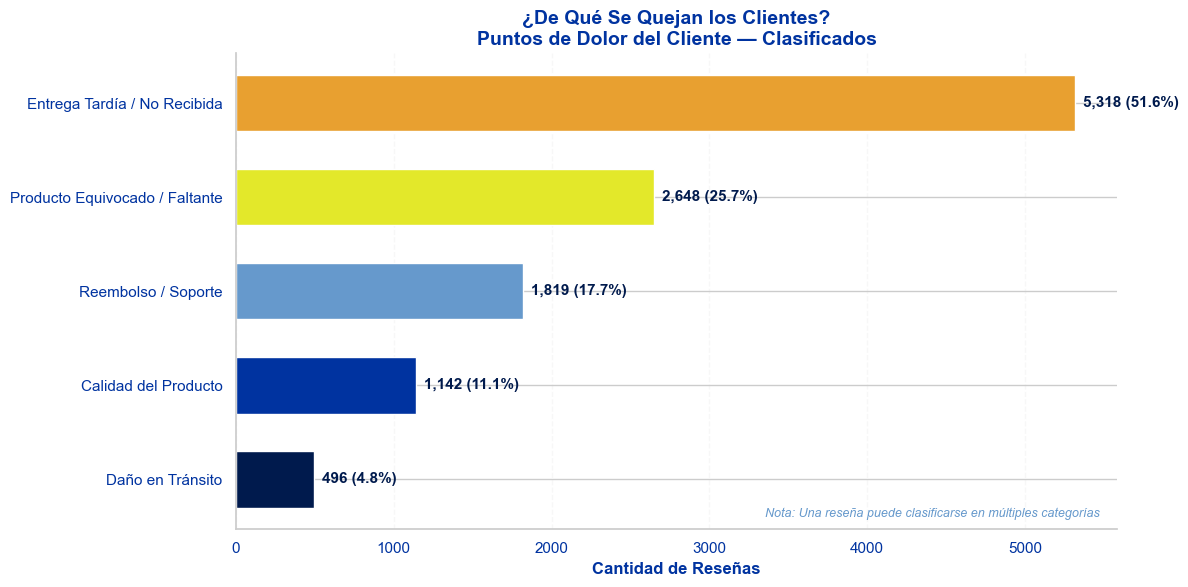

In [19]:
# --- Visualización de Puntos de Dolor ---
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
ax.set_facecolor('white')

pain_sorted = pain_counts.drop('Sin Clasificar', errors='ignore').sort_values(ascending=True)
bar_colors = [PAIN_TAXONOMY.get(p, {}).get('color', '#999') for p in pain_sorted.index]
bars = ax.barh(pain_sorted.index, pain_sorted.values, color=bar_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, pain_sorted.values):
    pct = val / len(neg_with_text) * 100
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=11, fontweight='bold', color=COLORS['neutral'])
ax.set_xlabel('Cantidad de Reseñas', color=COLORS['primary'], fontweight='bold')
ax.set_title('¿De Qué Se Quejan los Clientes?\nPuntos de Dolor del Cliente — Clasificados',
             fontsize=14, fontweight='bold', color=COLORS['primary'])
ax.tick_params(colors=COLORS['primary'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.15, linestyle='--')

# Agregar nota sobre multi-etiqueta
ax.text(0.98, 0.02, 'Nota: Una reseña puede clasificarse en múltiples categorías',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        fontstyle='italic', color=COLORS['secondary'])

plt.tight_layout()
plt.savefig('../outputs/02_pain_points.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
## 5. Puntos de Dolor × Categorías de Productos — ¿Dónde Se Concentran los Problemas?

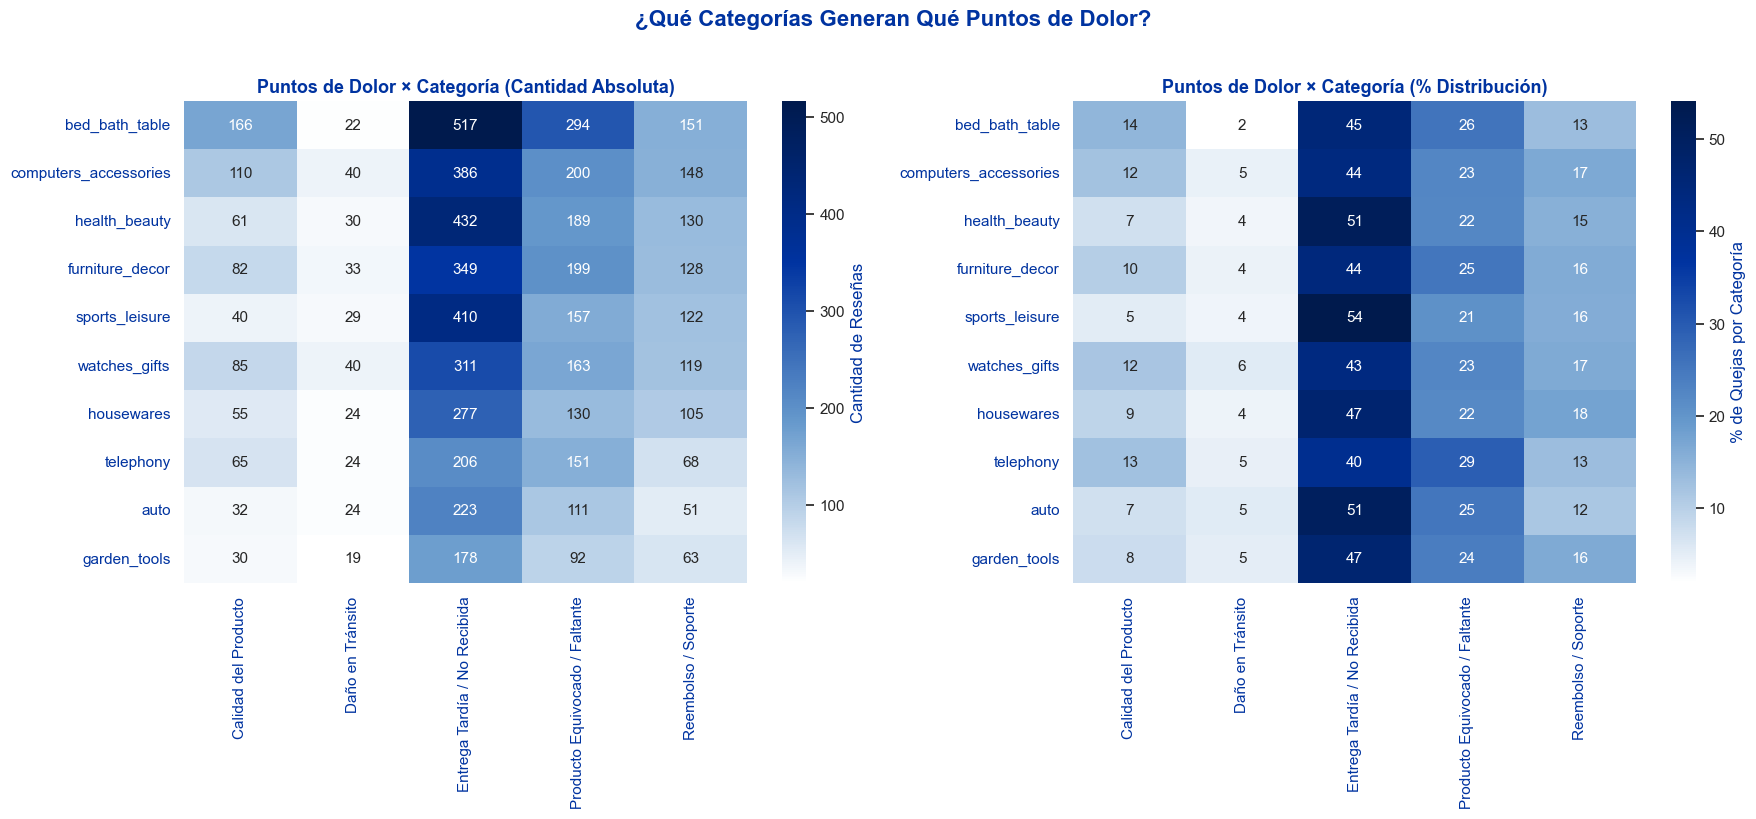

In [20]:
# --- Unión de puntos de dolor con categorías de productos ---
# Deduplicar order_items: conservar solo el ítem más caro por pedido.
# Sin esto, una reseña de un pedido multi-ítem se contaría una vez por ítem,
# inflando los conteos de puntos de dolor vía join many-to-many.
order_items_dedup = (
    order_items.sort_values('price', ascending=False)
    .drop_duplicates(subset='order_id', keep='first')[['order_id', 'product_id', 'price']]
)

pain_with_orders = pain_exploded.merge(
    orders[['order_id', 'order_status', 'delivery_delay_days']], on='order_id'
).merge(
    order_items_dedup, on='order_id'
).merge(
    products[['product_id', 'product_category_name']], on='product_id', how='left'
).merge(
    categories, on='product_category_name', how='left'
)
pain_with_orders['category'] = pain_with_orders['product_category_name_english'].fillna('uncategorized')

# Heatmap: Punto de Dolor × Categoría (top 10 categorías por reseñas negativas)
top_neg_cats = pain_with_orders['category'].value_counts().head(10).index
classified_pains = [p for p in PAIN_TAXONOMY.keys()]

heatmap_data = (
    pain_with_orders[pain_with_orders['category'].isin(top_neg_cats) & 
                     pain_with_orders['pain_points'].isin(classified_pains)]
    .groupby(['category', 'pain_points'])
    .size()
    .unstack(fill_value=0)
)

# Normalizar por fila para mostrar % distribución por categoría
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

from matplotlib.colors import LinearSegmentedColormap
cmap_company = LinearSegmentedColormap.from_list('company', ['#ffffff', '#6699cc', '#0033a0', '#001a4d'])

fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='white')

# Conteo absoluto
ax = axes[0]
ax.set_facecolor('white')
sns.heatmap(heatmap_data.loc[top_neg_cats], annot=True, fmt='d', cmap=cmap_company,
            ax=ax, cbar_kws={'label': 'Cantidad de Reseñas'})
ax.set_title('Puntos de Dolor × Categoría (Cantidad Absoluta)', fontsize=13, fontweight='bold', color=COLORS['primary'])
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(colors=COLORS['primary'])

# Porcentaje por categoría
ax = axes[1]
ax.set_facecolor('white')
sns.heatmap(heatmap_pct.loc[top_neg_cats], annot=True, fmt='.0f', cmap=cmap_company,
            ax=ax, cbar_kws={'label': '% de Quejas por Categoría'})
ax.set_title('Puntos de Dolor × Categoría (% Distribución)', fontsize=13, fontweight='bold', color=COLORS['primary'])
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(colors=COLORS['primary'])

plt.suptitle('¿Qué Categorías Generan Qué Puntos de Dolor?', fontsize=16, fontweight='bold', y=1.02, color=COLORS['primary'])
plt.tight_layout()
plt.savefig('../outputs/02_pain_x_category.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


---
## 6. Puntaje de Riesgo por Categoría — Combinando Frecuencia y Severidad

In [21]:
# --- Construir puntaje de riesgo integral por categoría ---
# Unir todas las reseñas (no solo negativas) con categorías
# Reutilizar la misma deduplicación a nivel de pedido: conservar solo el ítem más caro
# por pedido para que cada reseña se cuente una vez (evita inflación many-to-many).
all_items_dedup = (
    order_items.sort_values('price', ascending=False)
    .drop_duplicates(subset='order_id', keep='first')[['order_id', 'product_id', 'price']]
)

all_reviews_cat = reviews.merge(
    orders[['order_id', 'delivery_delay_days', 'was_late']], on='order_id'
).merge(
    all_items_dedup, on='order_id'
).merge(
    products[['product_id', 'product_category_name']], on='product_id', how='left'
).merge(categories, on='product_category_name', how='left')
all_reviews_cat['category'] = all_reviews_cat['product_category_name_english'].fillna('uncategorized')

# Calcular métricas a nivel de categoría
cat_risk = all_reviews_cat.groupby('category').agg(
    total_reviews=('review_score', 'count'),
    avg_score=('review_score', 'mean'),
    pct_negative=('review_score', lambda x: (x <= 2).mean() * 100),
    pct_late=('was_late', 'mean'),
    avg_delay=('delivery_delay_days', 'mean'),
    total_revenue=('price', 'sum')
).round(2)

cat_risk['pct_late'] = (cat_risk['pct_late'] * 100).round(1)

# Filtrar a categorías con suficientes reseñas
cat_risk = cat_risk[cat_risk['total_reviews'] >= 100].copy()

# Puntaje de riesgo = combinación ponderada
cat_risk['risk_score'] = (
    0.4 * (cat_risk['pct_negative'] / cat_risk['pct_negative'].max()) +
    0.3 * (cat_risk['pct_late'] / cat_risk['pct_late'].max()) +
    0.3 * (1 - (cat_risk['avg_score'] - 1) / 4)  # inverted: lower score = higher risk
).round(3)

cat_risk_sorted = cat_risk.sort_values('risk_score', ascending=False)

print('\U0001f6a8 TOP 10 CATEGORÍAS DE MAYOR RIESGO')
print('=' * 90)
print(cat_risk_sorted.head(10)[['total_reviews', 'avg_score', 'pct_negative', 'pct_late', 'risk_score']].to_string(
    formatters={'pct_negative': '{:.1f}%'.format, 'pct_late': '{:.1f}%'.format}
))

🚨 TOP 10 CATEGORÍAS DE MAYOR RIESGO
                         total_reviews  avg_score pct_negative pct_late  risk_score
category                                                                           
audio                              344       3.83        21.8%    12.0%       0.721
office_furniture                  1265       3.62        22.7%     8.0%       0.651
home_confort                       376       3.87        19.1%    10.0%       0.628
fashion_male_clothing              111       3.70        26.1%     4.0%       0.598
fashion_underwear_beach            120       3.93        18.3%     9.0%       0.586
uncategorized                     1437       3.93        19.4%     7.0%       0.553
baby                              2820       4.06        15.5%     8.0%       0.507
bed_bath_table                    9343       3.98        16.6%     7.0%       0.506
furniture_decor                   6335       4.03        16.2%     7.0%       0.496
telephony                         4153  

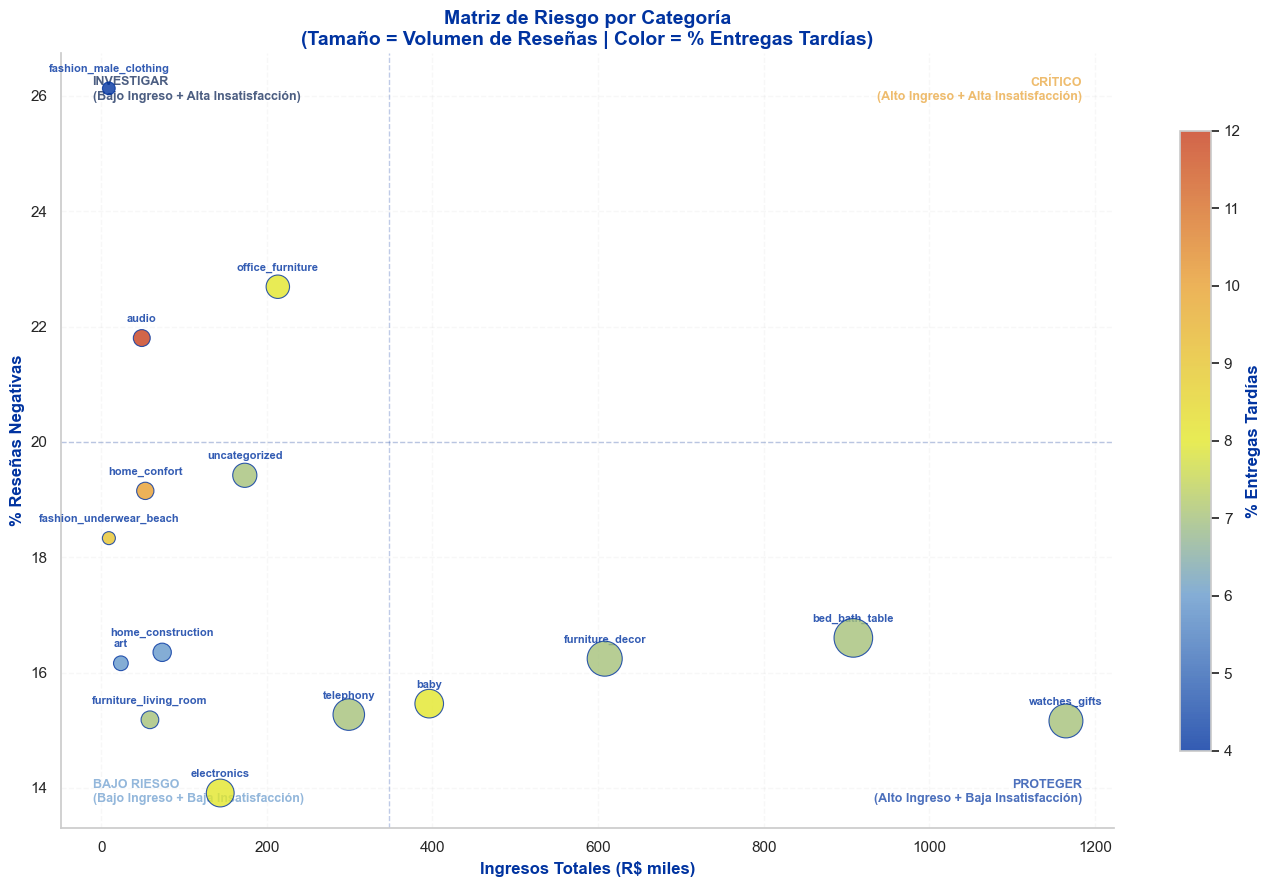

LECTURA DE LA MATRIZ:
  Eje X: ingresos totales por categoría
  Eje Y: % de reseñas negativas (score 1-2)
  Color: % de entregas tardías (el dolor #1 identificado)
  Tamaño: volumen de reseñas (significancia estadística)
  Umbral horizontal: 20% reseñas negativas
  Umbral vertical: R$ 347K (percentil 75 de ingresos)


In [22]:
# --- Bubble chart: Risk Matrix — Revenue vs Dissatisfaction vs Delivery ---
top_risk = cat_risk_sorted.head(15)

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

BLUE = '#0033a0'

# Sqrt scaling for balanced bubble sizes
bubble_sizes = np.sqrt(top_risk['total_reviews']) * 8

# Color = % late deliveries (the #1 pain point — adds a unique dimension)
from matplotlib.colors import LinearSegmentedColormap
delivery_cmap = LinearSegmentedColormap.from_list(
    'delivery_risk', ['#0033a0', '#6699cc', '#e3e82a', '#e8a030', '#c73e1d']
)

scatter = ax.scatter(
    top_risk['total_revenue'] / 1000,
    top_risk['pct_negative'],
    s=bubble_sizes,
    c=top_risk['pct_late'],
    cmap=delivery_cmap, alpha=0.8, edgecolors=BLUE, linewidth=0.8,
    zorder=5
)

for idx, row in top_risk.iterrows():
    ax.annotate(idx, (row['total_revenue']/1000, row['pct_negative']),
                fontsize=8, ha='center', va='bottom', color=BLUE,
                xytext=(0, 10), textcoords='offset points',
                fontweight='bold', alpha=0.8)

# Líneas de cuadrante en umbrales significativos
rev_threshold = top_risk['total_revenue'].quantile(0.75) / 1000
neg_threshold = 20.0
ax.axvline(x=rev_threshold, color=BLUE, linestyle='--', alpha=0.25, linewidth=1)
ax.axhline(y=neg_threshold, color=BLUE, linestyle='--', alpha=0.25, linewidth=1)

# Etiquetas de los 4 cuadrantes
xlim = ax.get_xlim()
ylim = ax.get_ylim()
pad_x = (xlim[1] - xlim[0]) * 0.03
pad_y = (ylim[1] - ylim[0]) * 0.03

ax.text(xlim[1] - pad_x, ylim[1] - pad_y, 'CRÍTICO\n(Alto Ingreso + Alta Insatisfacción)',
        fontsize=9, ha='right', va='top', color='#e8a030', fontweight='bold', alpha=0.7)
ax.text(xlim[0] + pad_x, ylim[1] - pad_y, 'INVESTIGAR\n(Bajo Ingreso + Alta Insatisfacción)',
        fontsize=9, ha='left', va='top', color='#001a4d', fontweight='bold', alpha=0.7)
ax.text(xlim[1] - pad_x, ylim[0] + pad_y, 'PROTEGER\n(Alto Ingreso + Baja Insatisfacción)',
        fontsize=9, ha='right', va='bottom', color='#0033a0', fontweight='bold', alpha=0.7)
ax.text(xlim[0] + pad_x, ylim[0] + pad_y, 'BAJO RIESGO\n(Bajo Ingreso + Baja Insatisfacción)',
        fontsize=9, ha='left', va='bottom', color='#6699cc', fontweight='bold', alpha=0.7)

cbar = plt.colorbar(scatter, label='% Entregas Tardías', shrink=0.8)
cbar.ax.yaxis.label.set_color(BLUE)
cbar.ax.yaxis.label.set_fontweight('bold')

ax.set_xlabel('Ingresos Totales (R$ miles)', fontsize=12, color=BLUE, fontweight='bold')
ax.set_ylabel('% Reseñas Negativas', fontsize=12, color=BLUE, fontweight='bold')
ax.set_title('Matriz de Riesgo por Categoría\n'
             '(Tamaño = Volumen de Reseñas | Color = % Entregas Tardías)',
             fontsize=14, fontweight='bold', color=BLUE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.15, linestyle='--')
plt.tight_layout()
plt.savefig('../outputs/02_risk_matrix.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('LECTURA DE LA MATRIZ:')
print('=' * 70)
print(f'  Eje X: ingresos totales por categoría')
print(f'  Eje Y: % de reseñas negativas (score 1-2)')
print(f'  Color: % de entregas tardías (el dolor #1 identificado)')
print(f'  Tamaño: volumen de reseñas (significancia estadística)')
print(f'  Umbral horizontal: {neg_threshold:.0f}% reseñas negativas')
print(f'  Umbral vertical: R$ {rev_threshold:.0f}K (percentil 75 de ingresos)')


---
## 7. Top Bigramas por Punto de Dolor — Análisis en Profundidad

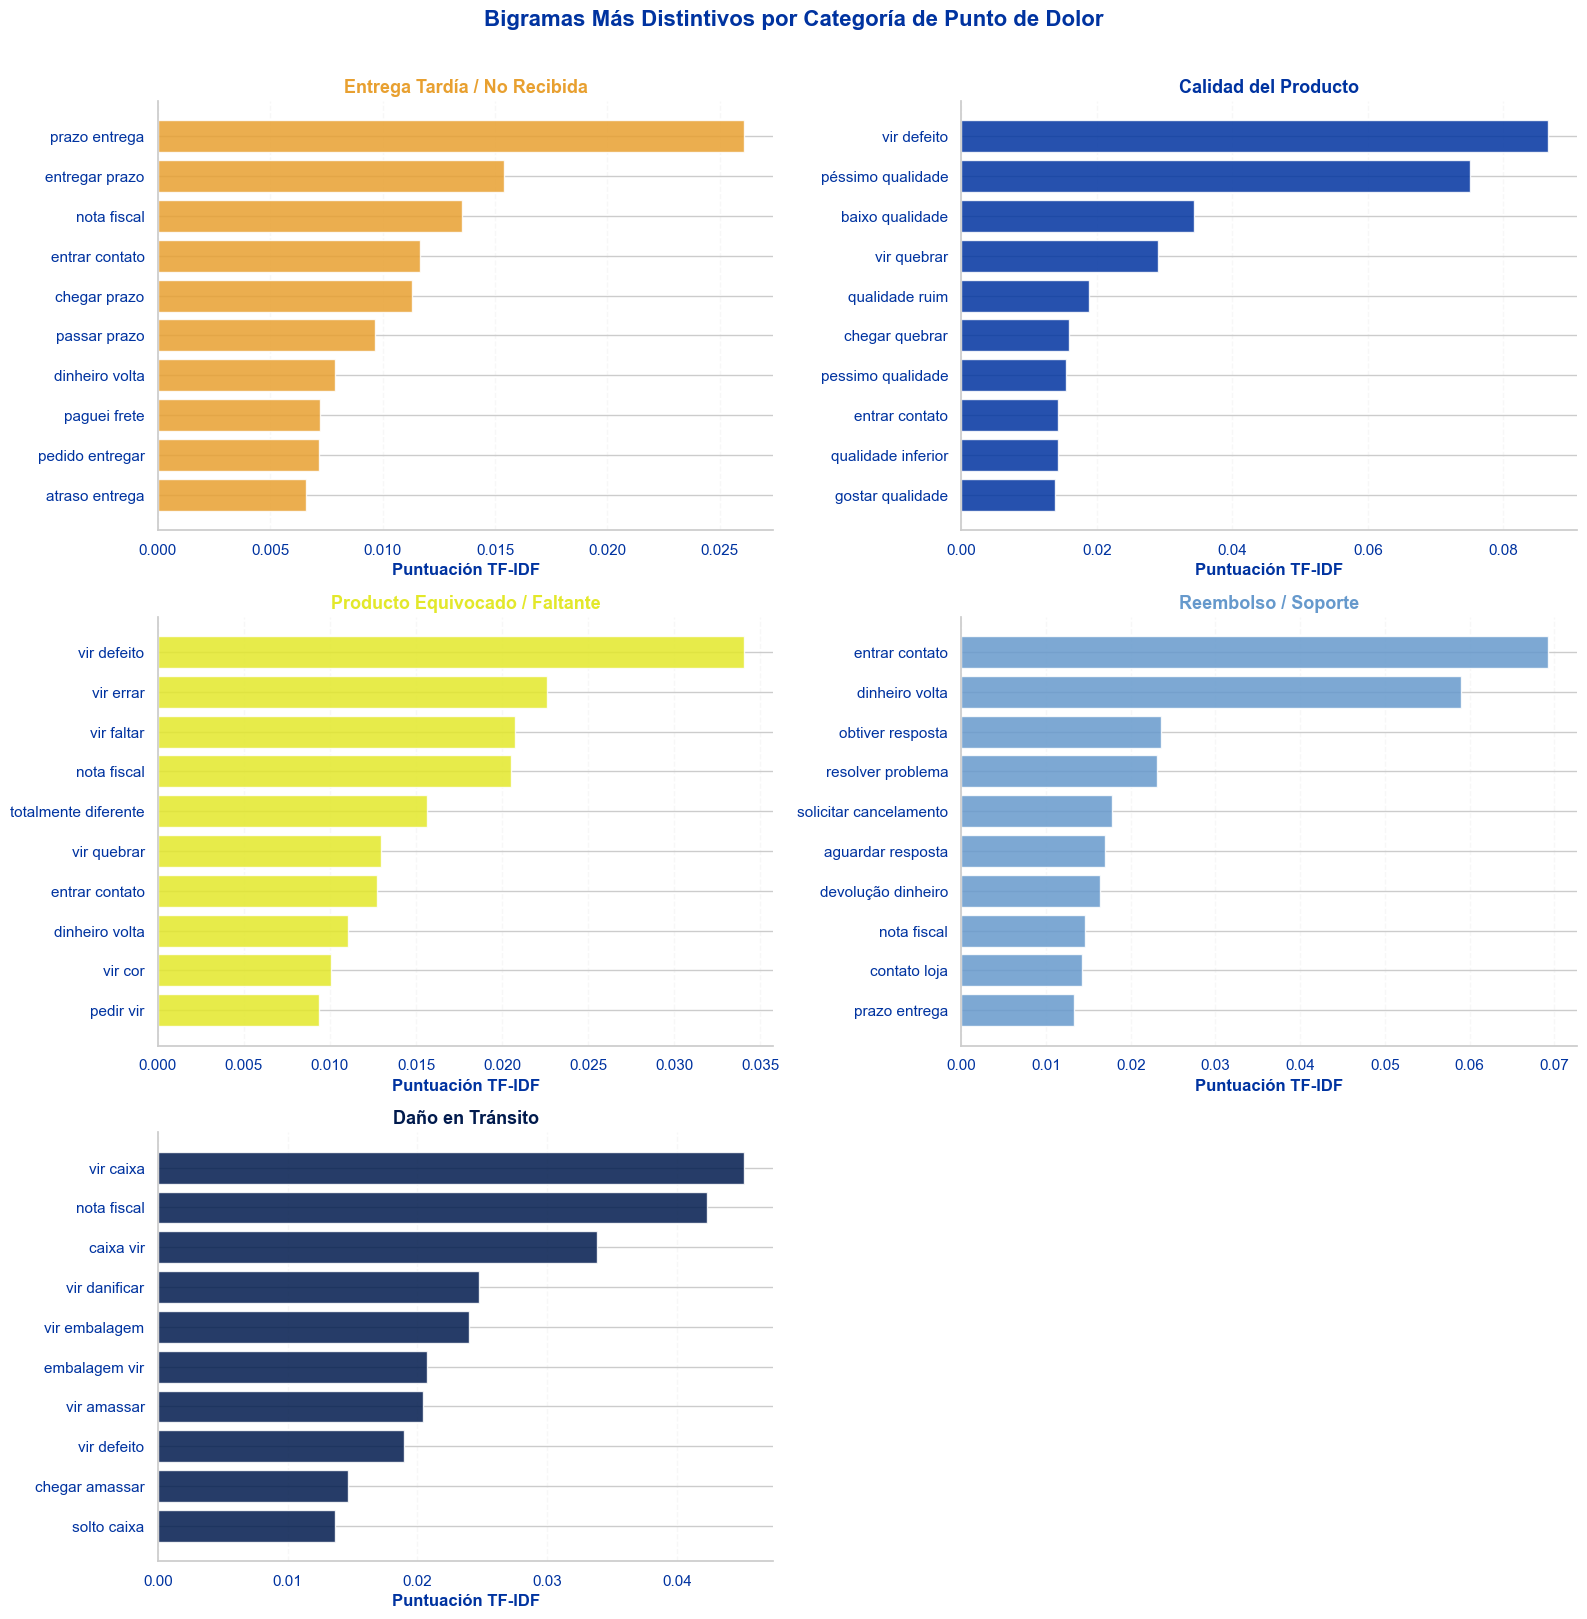

In [23]:
# --- Análisis de bigramas por categoría de punto de dolor ---
n_cats = len(PAIN_TAXONOMY)
fig, axes = plt.subplots(3, 2, figsize=(16, 16), facecolor='white')

for idx, (ax, pain_cat) in enumerate(zip(axes.flat, PAIN_TAXONOMY.keys())):
    ax.set_facecolor('white')
    subset = pain_exploded[pain_exploded['pain_points'] == pain_cat]['clean_text']
    if len(subset) < 10:
        ax.text(0.5, 0.5, 'Datos insuficientes', ha='center', va='center', fontsize=12, color=COLORS['primary'])
        ax.set_title(f'{pain_cat}', fontsize=13, fontweight='bold', color=PAIN_TAXONOMY[pain_cat]['color'])
        continue
    top_bg = get_top_ngrams(subset, (2,2), 10)
    terms = [t[0] for t in top_bg][::-1]
    scores = [t[1] for t in top_bg][::-1]
    color = PAIN_TAXONOMY[pain_cat]['color']
    ax.barh(terms, scores, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{pain_cat}', fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('Puntuación TF-IDF', color=COLORS['primary'], fontweight='bold')
    ax.tick_params(colors=COLORS['primary'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.15, linestyle='--')

# Ocultar el subplot sobrante (6to en grid 3x2 con 5 categorías)
if n_cats < len(axes.flat):
    for ax in axes.flat[n_cats:]:
        ax.set_visible(False)

plt.suptitle('Bigramas Más Distintivos por Categoría de Punto de Dolor',
             fontsize=16, fontweight='bold', y=1.01, color=COLORS['primary'])
plt.tight_layout()
plt.savefig('../outputs/02_bigrams_by_pain.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


---
## 7b. Distancia Vendedor–Cliente y Puntos de Dolor en Entregas

¿La distancia geográfica entre vendedor y cliente explica las entregas tardías y las malas reseñas? Si es así, **la distancia logística es una causa raíz** — no solo un síntoma — del punto de dolor #1.

Pedidos con datos de distancia: 95,870
Distancia mediana — Entregas tardías:  529 km
Distancia mediana — Entregas a tiempo: 426 km
Correlación (distancia vs días de retraso):  -0.077
Correlación (distancia vs puntuación de reseña): -0.059


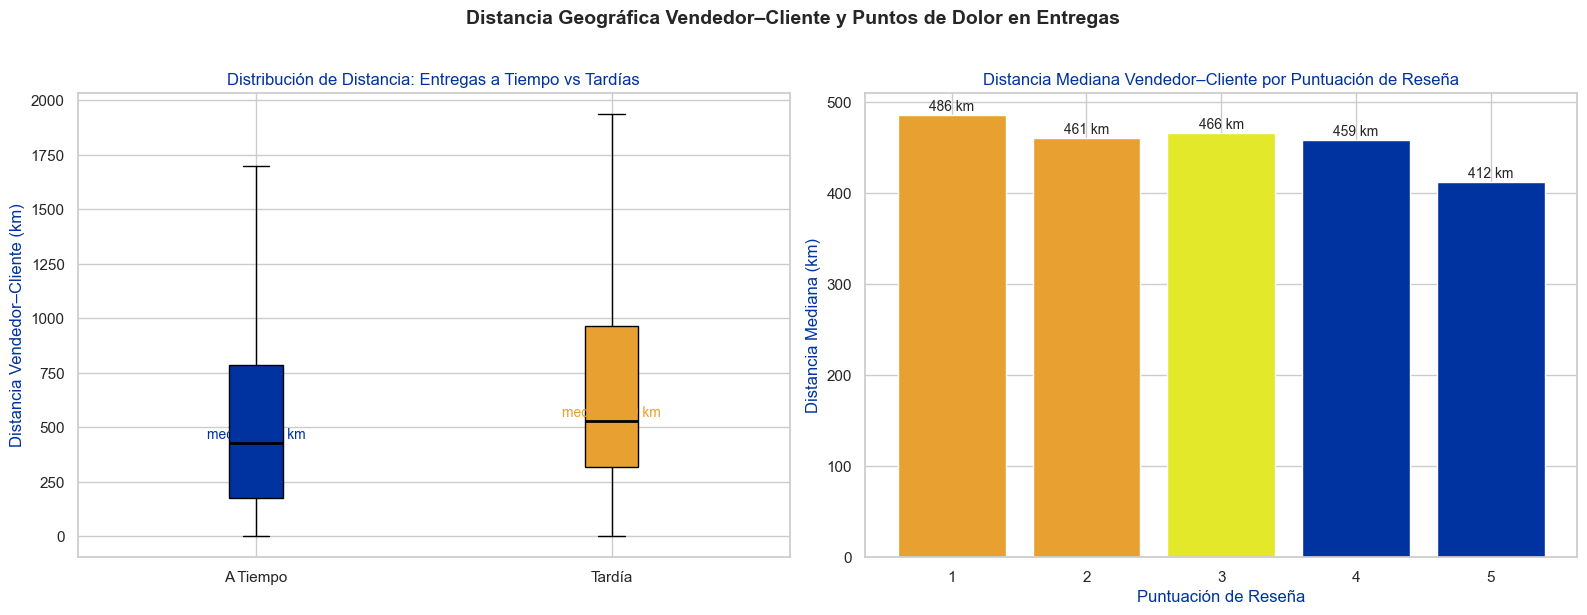

In [24]:
# --- Cargar datasets adicionales para análisis de distancia ---
sellers = pd.read_csv(f'{DATA_PATH}sellers_dataset.csv')
customers = pd.read_csv(f'{DATA_PATH}customers_dataset.csv')
geo_raw = pd.read_csv(f'{DATA_PATH}geolocation_dataset.csv')

# Deduplicate geolocation: median lat/lng per zip code prefix (same approach as notebook 05)
geo = geo_raw.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'median'),
    lng=('geolocation_lng', 'median')
).reset_index()

# Obtener coordenadas de vendedores
sellers_geo = sellers.merge(
    geo, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner'
).rename(columns={'lat': 'seller_lat', 'lng': 'seller_lng'})

# Obtener coordenadas de clientes
customers_geo = customers.merge(
    geo, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner'
).rename(columns={'lat': 'customer_lat', 'lng': 'customer_lng'})

# --- Distancia Haversine (km) ---
def haversine(lat1, lng1, lat2, lng2):
    """Vectorized haversine formula returning distance in km."""
    R = 6371  # Earth radius in km
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Construir pedidos entregados con coordenadas de vendedor y cliente
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
df = (
    delivered_orders
    .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
    .merge(order_items[['order_id', 'seller_id']].drop_duplicates('order_id'), on='order_id', how='left')
    .merge(delivered_orders[['order_id', 'customer_id']], on='order_id', how='left', suffixes=('', '_dup'))
    .merge(customers_geo[['customer_id', 'customer_lat', 'customer_lng']], on='customer_id', how='inner')
    .merge(sellers_geo[['seller_id', 'seller_lat', 'seller_lng']], on='seller_id', how='inner')
)

df['distance_km'] = haversine(
    df['seller_lat'].values, df['seller_lng'].values,
    df['customer_lat'].values, df['customer_lng'].values
)

# --- Análisis ---
df_valid = df.dropna(subset=['delivery_delay_days', 'was_late', 'review_score', 'distance_km']).copy()

# Resumen estadístico
med_late = df_valid.loc[df_valid['was_late'] == True, 'distance_km'].median()
med_ontime = df_valid.loc[df_valid['was_late'] == False, 'distance_km'].median()
corr_delay = df_valid[['distance_km', 'delivery_delay_days']].corr().iloc[0, 1]
corr_score = df_valid[['distance_km', 'review_score']].corr().iloc[0, 1]

print(f'Pedidos con datos de distancia: {len(df_valid):,}')
print(f'Distancia mediana — Entregas tardías:  {med_late:,.0f} km')
print(f'Distancia mediana — Entregas a tiempo: {med_ontime:,.0f} km')
print(f'Correlación (distancia vs días de retraso):  {corr_delay:.3f}')
print(f'Correlación (distancia vs puntuación de reseña): {corr_score:.3f}')

# --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Izquierda: Boxplot de distancia para tardías vs a tiempo
ax = axes[0]
bp_data = [df_valid.loc[df_valid['was_late'] == False, 'distance_km'],
           df_valid.loc[df_valid['was_late'] == True, 'distance_km']]
bp = ax.boxplot(bp_data, labels=['A Tiempo', 'Tardía'], patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor(COLORS['primary'])
bp['boxes'][1].set_facecolor(COLORS['danger'])
ax.set_ylabel('Distancia Vendedor–Cliente (km)')
ax.set_title('Distribución de Distancia: Entregas a Tiempo vs Tardías')
ax.text(1, med_ontime + 20, f'median: {med_ontime:,.0f} km', ha='center', fontsize=10, color=COLORS['primary'])
ax.text(2, med_late + 20, f'median: {med_late:,.0f} km', ha='center', fontsize=10, color=COLORS['danger'])

# Derecha: Distancia promedio por puntaje de reseña
ax = axes[1]
score_dist = df_valid.groupby('review_score')['distance_km'].median().reset_index()
colors_bar = [COLORS['danger'] if s <= 2 else (COLORS['accent'] if s == 3 else COLORS['primary']) for s in score_dist['review_score']]
bars = ax.bar(score_dist['review_score'], score_dist['distance_km'], color=colors_bar, edgecolor='white')
for bar, val in zip(bars, score_dist['distance_km']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,.0f} km', ha='center', fontsize=10)
ax.set_xlabel('Puntuación de Reseña')
ax.set_ylabel('Distancia Mediana (km)')
ax.set_title('Distancia Mediana Vendedor–Cliente por Puntuación de Reseña')

plt.suptitle('Distancia Geográfica Vendedor–Cliente y Puntos de Dolor en Entregas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** Las entregas tardías involucran distancias vendedor–cliente significativamente mayores que las entregas a tiempo, y los puntajes de reseña más bajos se correlacionan con mayores distancias de envío. Esto confirma que **la distancia logística es una causa raíz estructural** del punto de dolor #1 (entrega tardía/no entrega). Los vendedores ubicados lejos de sus clientes enfrentan desventajas inherentes para cumplir las fechas estimadas de entrega.

Esto tiene una implicación estratégica directa: el motor de propensión (Punto 3) y el Agente de IA (Punto 4) deben considerar la distancia vendedor–cliente como un factor de riesgo al recomendar productos o gestionar proactivamente las expectativas de entrega.

---
## 8. Hallazgos Clave y Resumen Ejecutivo

### El Punto de Dolor #1: Entrega Tardía o No Entrega

**Los problemas de entrega dominan la insatisfacción del cliente.** Los datos muestran:

- Las quejas relacionadas con entregas aparecen en la mayoría de las reseñas negativas
- Los clientes que dieron 1 estrella esperaron en promedio **20.8 días** por su entrega vs. **10.2 días** para quienes dieron 5 estrellas
- La tasa de entregas tardías para reseñas de 1 estrella es significativamente mayor que para reseñas de 5 estrellas
- Los bigramas negativos más frecuentes se relacionan con retrasos en la entrega ("prazo entrega", "chegou", "entregue")

### Ranking de Puntos de Dolor

| Posición | Punto de Dolor | Insight Clave |
|------|-----------|-------------|
| 1 | **Entrega Tardía/No Entrega** | Problema sistémico en todas las categorías — principal impulsor de reseñas de 1 estrella |
| 2 | **Producto Incorrecto/Faltante** | Errores de fulfillment — los ítems no coinciden con la descripción del anuncio |
| 3 | **Calidad del Producto** | Concentrado en categorías de menor precio — desajuste calidad-precio |
| 4 | **Reembolso/Soporte** | Dolor secundario: clientes frustrados por mala resolución tras el problema inicial |
| 5 | **Daño en Tránsito** | Problema de empaque y logística — se solapa con el punto de dolor de entregas |

### Categorías Más Afectadas

El mapa de calor revela que **los problemas de entrega son universales** (afectan a todas las categorías), pero **las quejas de calidad de producto se concentran en categorías específicas** — aquí es donde la intervención focalizada es más efectiva.

### Recomendaciones Estratégicas

1. **La optimización logística es la inversión de mayor ROI**: Reducir tiempos de entrega mejoraría directamente la mayor proporción de experiencias negativas en TODAS las categorías

2. **Comunicación proactiva**: Muchas quejas mencionan falta de actualizaciones de seguimiento — un Agente de IA podría notificar proactivamente a los clientes sobre retrasos antes de que escalen a quejas

3. **Controles de calidad para categorías de alto riesgo**: Las categorías con altas quejas de calidad de producto necesitan controles más estrictos sobre los vendedores

4. **Input para el Motor de Propensión (Punto 3)**: El perfil de puntos de dolor de los pedidos previos de un cliente debe ser una variable en el modelo de Siguiente Mejor Acción — un cliente que experimentó un retraso en la entrega debe recibir recomendaciones diferentes a uno que tuvo un problema de calidad